In [1]:
import os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

In [2]:
SEED = 42
np.random.seed(SEED)

In [3]:
# ---------------------------
# 1) Load data
# ---------------------------
CSV_PATH = "/kaggle/input/home-data-for-ml-course/train.csv" 
assert os.path.exists(CSV_PATH), "train.csv not found in working directory."
df = pd.read_csv(CSV_PATH)

In [4]:
TARGET = "SalePrice"
y_raw = df[TARGET].copy().astype(float)
X = df.drop(columns=[TARGET])

In [5]:
# ---------------------------
# 2) Train/Validation split (holdout)
# ---------------------------
from sklearn.model_selection import train_test_split

# Log-transform target for stability
y = np.log1p(y_raw.values)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

In [6]:
# ---------------------------
# 3) Preprocessing: impute + one-hot + scale
# ---------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Use sparse=False for broad sklearn compatibility
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

X_train_p = preprocessor.fit_transform(X_train)
X_valid_p = preprocessor.transform(X_valid)

feat_dim = X_train_p.shape[1]
print(f"Preprocessed feature dimension: {feat_dim}")

Preprocessed feature dimension: 286


In [7]:
# ---------------------------
# 4) Metrics
# ---------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mape(y_true, y_pred, eps=1e-8):
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

def format_money(x):
    return f"{int(round(x)):,}"

def inv_log1p(yhat_log):
    return np.expm1(yhat_log)

# Keep dollar-space versions for evaluation
y_valid_dollars = np.expm1(y_valid)

In [8]:
# ---------------------------
# 5) Tuned XGBoost (your best params)
# ---------------------------
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=935,
    max_depth=3,
    learning_rate=0.04078621020707325,
    subsample=0.7900071879843472,
    colsample_bytree=0.68075574530318,
    reg_lambda=0.8199380720864932,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

xgb.fit(
    X_train_p, y_train,
    eval_set=[(X_valid_p, y_valid)],
    verbose=False
)

y_pred_valid_xgb_log = xgb.predict(X_valid_p)
y_pred_valid_xgb_dollars = inv_log1p(y_pred_valid_xgb_log)

rmse_xgb = np.sqrt(mean_squared_error(y_valid_dollars, y_pred_valid_xgb_dollars))
mae_xgb  = mean_absolute_error(y_valid_dollars, y_pred_valid_xgb_dollars)
mape_xgb = mape(y_valid_dollars, y_pred_valid_xgb_dollars)

print(f"✅ Tuned XGBoost — RMSE: ${rmse_xgb:,.0f} | MAE: ${mae_xgb:,.0f} | MAPE: {mape_xgb:.2f}%")

✅ Tuned XGBoost — RMSE: $24,310 | MAE: $14,713 | MAPE: 8.78%


In [9]:
# ---------------------------
# 6) MLP (ANN) — Multilayer Perceptron for tabular regression
# ---------------------------
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers, losses, metrics, Model

tf.random.set_seed(SEED)

def build_mlp(input_dim: int) -> Model:
    inp = layers.Input(shape=(input_dim,), name="inp")

    x = layers.Dense(128, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)  # Predict log-price

    model = Model(inp, out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss=losses.MeanSquaredError(),
        metrics=[metrics.MeanAbsoluteError(name="mae")]
    )
    return model

mlp = build_mlp(feat_dim)

es = callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)
rlrop = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=15, min_lr=1e-6)

history = mlp.fit(
    X_train_p, y_train,
    validation_data=(X_valid_p, y_valid),
    epochs=1000,
    batch_size=256,
    callbacks=[es, rlrop],
    verbose=0
)

y_pred_valid_mlp_log = mlp.predict(X_valid_p, verbose=0).ravel()
y_pred_valid_mlp_dollars = inv_log1p(y_pred_valid_mlp_log)

rmse_mlp = np.sqrt(mean_squared_error(y_valid_dollars, y_pred_valid_mlp_dollars))
mae_mlp  = mean_absolute_error(y_valid_dollars, y_pred_valid_mlp_dollars)
mape_mlp = mape(y_valid_dollars, y_pred_valid_mlp_dollars)

print(f"✅ MLP (ANN) — RMSE: ${rmse_mlp:,.0f} | MAE: ${mae_mlp:,.0f} | MAPE: {mape_mlp:.2f}%")

2025-10-27 16:14:18.431463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761581658.630800      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761581658.689317      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1761581669.807974      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1761581673.902182      98 service.cc:148] XLA service 0x7f6060001fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761581673.902955      

✅ MLP (ANN) — RMSE: $74,008 | MAE: $48,853 | MAPE: 28.09%


In [10]:
# ---------------------------
# 7) Results table
# ---------------------------
res = pd.DataFrame([
    {
        "Model": "XGBoost (ML - tuned)",
        "Holdout_RMSE_$": format_money(rmse_xgb),
        "Holdout_MAE_$":  format_money(mae_xgb),
        "Holdout_MAPE_%": f"{mape_xgb:.2f}",
    },
    {
        "Model": "MLP (ANN)",
        "Holdout_RMSE_$": format_money(rmse_mlp),
        "Holdout_MAE_$":  format_money(mae_mlp),
        "Holdout_MAPE_%": f"{mape_mlp:.2f}",
    }
])

print("\n=== Holdout Performance (inverse-transformed, $) ===")
print(res.to_string(index=False))

# Save results
res.to_csv("holdout_results_xgb_vs_mlp.csv", index=False)


=== Holdout Performance (inverse-transformed, $) ===
               Model Holdout_RMSE_$ Holdout_MAE_$ Holdout_MAPE_%
XGBoost (ML - tuned)         24,310        14,713           8.78
           MLP (ANN)         74,008        48,853          28.09


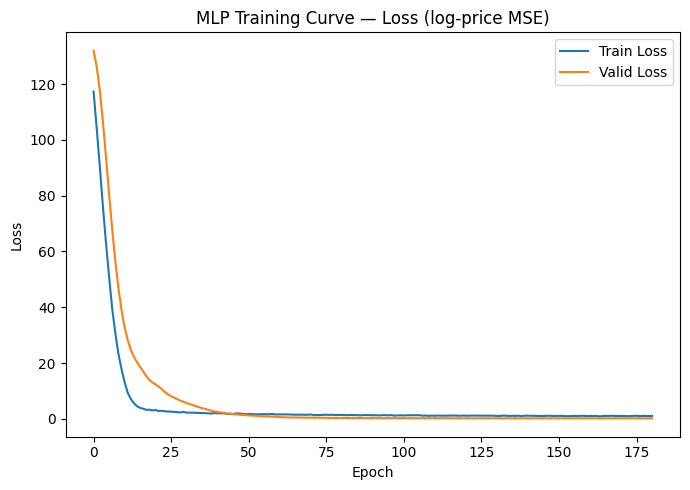

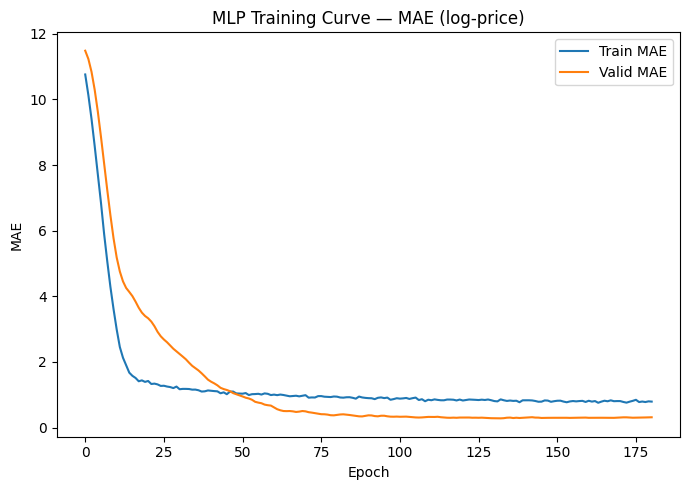

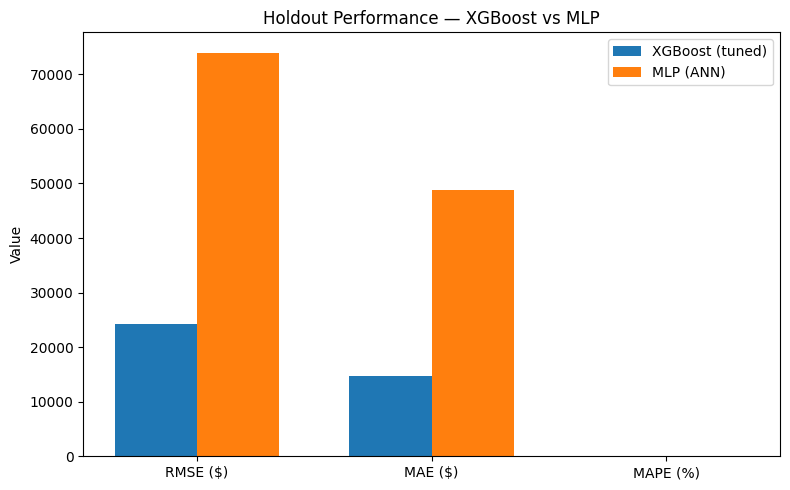

In [11]:
# ---------------------------
# 8) Visualizations
# ---------------------------
import matplotlib.pyplot as plt

# 8.1 MLP Loss Curve
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Valid Loss")
plt.title("MLP Training Curve — Loss (log-price MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("mlp_loss_curve.png", dpi=150)
plt.show()

# 8.2 MLP MAE Curve
if "mae" in history.history and "val_mae" in history.history:
    plt.figure(figsize=(7,5))
    plt.plot(history.history["mae"], label="Train MAE")
    plt.plot(history.history["val_mae"], label="Valid MAE")
    plt.title("MLP Training Curve — MAE (log-price)")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.tight_layout()
    plt.savefig("mlp_mae_curve.png", dpi=150)
    plt.show()

# 8.3 Side-by-side bar chart: XGBoost vs MLP (RMSE / MAE / MAPE)
metrics_names = ["RMSE ($)", "MAE ($)", "MAPE (%)"]
xgb_vals = [rmse_xgb, mae_xgb, mape_xgb]
mlp_vals = [rmse_mlp, mae_mlp, mape_mlp]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, xgb_vals, width, label="XGBoost (tuned)")
plt.bar(x + width/2, mlp_vals, width, label="MLP (ANN)")
plt.xticks(x, metrics_names)
plt.title("Holdout Performance — XGBoost vs MLP")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("model_comparison_metrics.png", dpi=150)
plt.show()

In [14]:
# ==== TARGET STANDARDIZATION IN LOG SPACE (put where you create y) ====
y_log = np.log1p(y_raw.values)
y_mean, y_std = y_log.mean(), y_log.std()
y = (y_log - y_mean) / y_std  # standardized log target

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# ... your preprocessor code stays the same ...
X_train_p = preprocessor.fit_transform(X_train)
X_valid_p = preprocessor.transform(X_valid)

# ==== STRONGER MLP ====
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers, losses, regularizers, Model

def build_mlp(input_dim: int) -> Model:
    reg = regularizers.l2(1e-4)
    inp = layers.Input(shape=(input_dim,), name="inp")

    x = layers.Dense(256, activation="relu", kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    out = layers.Dense(1, activation="linear")(x)  # standardized log-price

    model = Model(inp, out)
    # AdamW + Huber loss
    try:
        opt = optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    except:
        opt = optimizers.Adam(learning_rate=1e-3)  # fallback
    model.compile(optimizer=opt, loss=losses.Huber(), metrics=["mae"])
    return model

mlp = build_mlp(X_train_p.shape[1])

# Cosine decay restarts is great; fallback to ReduceLROnPlateau if needed
schedule = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=12, min_lr=1e-6, verbose=1
)
es = callbacks.EarlyStopping(monitor="val_loss", patience=40, restore_best_weights=True, verbose=1)

hist = mlp.fit(
    X_train_p, y_train,
    validation_data=(X_valid_p, y_valid),
    epochs=600,
    batch_size=1024,
    callbacks=[schedule, es],
    verbose=0
)

# ==== EVALUATION (invert standardization + log) ====
y_valid_dollar = np.expm1(y_valid * y_std + y_mean)
y_pred_valid_std = mlp.predict(X_valid_p, verbose=0).ravel()
y_pred_valid_dollar = np.expm1(y_pred_valid_std * y_std + y_mean)

rmse_mlp = np.sqrt(mean_squared_error(y_valid_dollar, y_pred_valid_dollar))
mae_mlp  = mean_absolute_error(y_valid_dollar, y_pred_valid_dollar)
mape_mlp = mape(y_valid_dollar, y_pred_valid_dollar)

print(f"✅ Stronger MLP — RMSE: ${rmse_mlp:,.0f} | MAE: ${mae_mlp:,.0f} | MAPE: {mape_mlp:.2f}%")


Epoch 213: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 232: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 244: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 265: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 277: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 289: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 295: early stopping
Restoring model weights from the end of the best epoch: 255.
✅ Stronger MLP — RMSE: $27,076 | MAE: $15,324 | MAPE: 8.91%


#numeric: 37 | #categorical: 43
Sample cardinalities: {'MSZoning': 6, 'Street': 3, 'Alley': 4, 'LotShape': 5, 'LandContour': 5}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ MSZoning_inp        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Street_inp          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Alley_inp           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LotShape_inp        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LandContour_inp     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Utilities_inp       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LotConfig_inp       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LandSlope_inp       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Neighborhood_inp    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Condition1_inp      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Condition2_inp      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BldgType_inp        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ HouseStyle_inp      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RoofStyle_inp       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RoofMatl_inp        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Exterior1st_inp     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Exterior2nd_inp     │ (None, 1)         │          0 │ -               

 Total params: 306,498 (1.17 MB)

 Trainable params: 304,706 (1.16 MB)

 Non-trainable params: 1,792 (7.00 KB)


Epoch 175: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 219: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 252: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 264: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 276: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 281: early stopping
Restoring model weights from the end of the best epoch: 241.
✅ Embedding Wide&Deep MLP — RMSE: $25,228 | MAE: $15,648 | MAPE: 9.25%


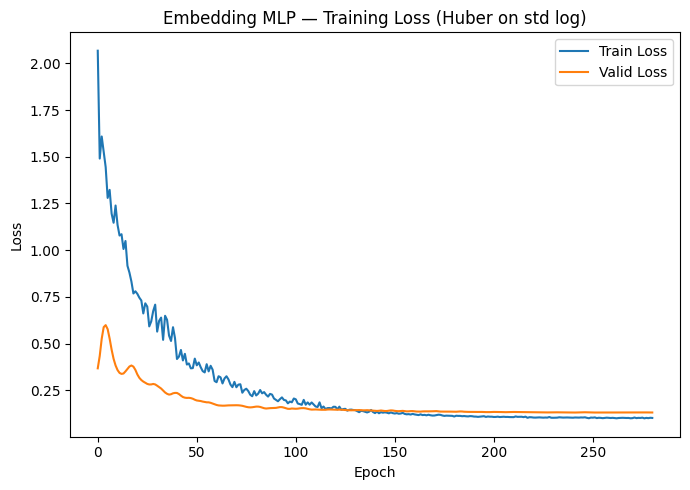

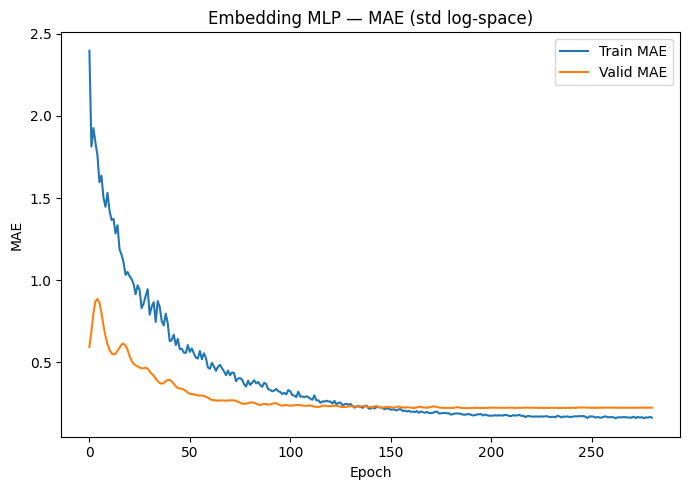

In [17]:
import os, warnings, math, random
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

CSV_PATH = "/kaggle/input/home-data-for-ml-course/train.csv"
assert os.path.exists(CSV_PATH), "train.csv not found."

# ---------------------------
# 1) Load & basic split
# ---------------------------
df = pd.read_csv(CSV_PATH)
TARGET = "SalePrice"

y_raw = df[TARGET].astype(float).values
X = df.drop(columns=[TARGET])

from sklearn.model_selection import train_test_split, KFold

# Standardize log target (stabilizes optimization)
y_log = np.log1p(y_raw)
y_mean, y_std = y_log.mean(), y_log.std()
y_std_target = (y_log - y_mean) / y_std  # standardized log-price

X_train_df, X_valid_df, y_train_std, y_valid_std = train_test_split(
    X, y_std_target, test_size=0.2, random_state=SEED
)

# ---------------------------
# 2) TRAIN-ONLY category maps + rare binning
# ---------------------------
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

RARE_MIN_COUNT = 10  # collapse categories with <10 occurrences into __RARE__

def build_cat_map(series: pd.Series, rare_min_count=10):
    s = series.fillna("__NA__").astype(str)
    vc = s.value_counts(dropna=False)
    rare_tokens = set(vc[vc < rare_min_count].index.astype(str))
    s2 = s.apply(lambda v: "__RARE__" if v in rare_tokens else v)
    tokens = ["__UNK__"] + sorted(set(s2))  # 0 reserved for unknowns
    tok2id = {t:i for i,t in enumerate(tokens)}
    return tok2id, rare_tokens

cat_maps = {}
rare_bins = {}
for c in cat_cols:
    tok2id, rare = build_cat_map(X_train_df[c], RARE_MIN_COUNT)
    cat_maps[c] = tok2id
    rare_bins[c] = rare

def transform_cat(series: pd.Series, colname: str):
    tok2id = cat_maps[colname]
    rare_tokens = rare_bins[colname]
    s = series.fillna("__NA__").astype(str)
    s = s.apply(lambda v: "__RARE__" if v in rare_tokens else v)
    return s.apply(lambda v: tok2id.get(v, 0)).astype("int32").values  # 0=__UNK__

# ---------------------------
# 3) Numeric preprocessing (median + standardize) on TRAIN only
# ---------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_imputer = SimpleImputer(strategy="median")
num_scaler  = StandardScaler()

X_train_num = num_imputer.fit_transform(X_train_df[num_cols])
X_train_num = num_scaler.fit_transform(X_train_num)

X_valid_num = num_scaler.transform(num_imputer.transform(X_valid_df[num_cols]))

# ---------------------------
# 4) Build categorical arrays (int indices)
# ---------------------------
X_train_cats = {c: transform_cat(X_train_df[c], c) for c in cat_cols}
X_valid_cats = {c: transform_cat(X_valid_df[c], c) for c in cat_cols}

# Cardinalities per categorical (incl. __UNK__)
cardinalities = {c: (max(X_train_cats[c].max(), X_valid_cats[c].max()) + 1) for c in cat_cols}

print(f"#numeric: {X_train_num.shape[1]} | #categorical: {len(cat_cols)}")
print("Sample cardinalities:", dict(list(cardinalities.items())[:5]))

# ---------------------------
# 5) Build Wide&Deep Embedding MLP
# ---------------------------
import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers, losses, regularizers, Model, Input

tf.random.set_seed(SEED)

def embed_dim_for_card(card):
    # heuristic: capped small power-law
    return int(min(50, round(1.6 * (card ** 0.56))))

def build_embedding_mlp(n_num_features: int, cat_cards: dict):
    # numeric input
    num_inp = Input(shape=(n_num_features,), name="num_inp")

    # categorical inputs + embeddings
    cat_inps = []
    cat_embs = []
    for c, card in cat_cards.items():
        inp = Input(shape=(1,), dtype="int32", name=f"{c}_inp")
        dim = embed_dim_for_card(card)
        emb = layers.Embedding(input_dim=card, output_dim=dim, name=f"{c}_emb")(inp)
        emb = layers.Reshape((dim,))(emb)
        cat_inps.append(inp)
        cat_embs.append(emb)

    # concat features
    x = layers.Concatenate(name="concat_all")([num_inp] + cat_embs)

    # regularization
    x = layers.GaussianNoise(0.01)(x)
    reg = regularizers.l2(1e-4)

    # wide (linear) branch
    wide = layers.Dense(128, activation="linear", kernel_regularizer=reg, name="wide")(x)

    # deep branch
    d = layers.Dense(512, activation="relu", kernel_regularizer=reg)(x)
    d = layers.BatchNormalization()(d)
    d = layers.Dropout(0.30)(d)

    d = layers.Dense(256, activation="relu", kernel_regularizer=reg)(d)
    d = layers.BatchNormalization()(d)
    d = layers.Dropout(0.30)(d)

    d = layers.Dense(128, activation="relu", kernel_regularizer=reg)(d)
    d = layers.BatchNormalization()(d)
    d = layers.Dropout(0.25)(d)

    fused = layers.Concatenate(name="fuse")([wide, d])

    # optional polynomial cross features (light touch)
    cross = layers.Concatenate(name="cross")([fused, layers.Multiply()([fused, fused])])

    out = layers.Dense(1, activation="linear", name="y")(cross)  # predicts standardized log target

    model = Model([num_inp] + cat_inps, out)

    # Optimizer: AdamW if available, else Adam
    try:
        opt = optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    except:
        opt = optimizers.Adam(learning_rate=1e-3)

    model.compile(optimizer=opt, loss=losses.Huber(), metrics=["mae"])
    return model

# Prepare Keras inputs
def make_inputs(num_array, cat_dict):
    inputs = {"num_inp": num_array.astype("float32")}
    for c, arr in cat_dict.items():
        inputs[f"{c}_inp"] = arr.reshape(-1, 1).astype("int32")
    return inputs

train_inputs = make_inputs(X_train_num, X_train_cats)
valid_inputs = make_inputs(X_valid_num, X_valid_cats)

model = build_embedding_mlp(X_train_num.shape[1], cardinalities)
model.summary()

# ---------------------------
# 6) Train
# ---------------------------
es = callbacks.EarlyStopping(monitor="val_loss", patience=40, restore_best_weights=True, verbose=1)
rlrop = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=12, min_lr=1e-6, verbose=1)

history = model.fit(
    train_inputs, y_train_std,
    validation_data=(valid_inputs, y_valid_std),
    epochs=600,
    batch_size=1024,
    callbacks=[es, rlrop],
    verbose=0
)

# ---------------------------
# 7) Evaluate (inverse std + log to dollars)
# ---------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mape(y_true, y_pred, eps=1e-8):
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

y_valid_dollars = np.expm1(y_valid_std * y_std + y_mean)
y_pred_std = model.predict(valid_inputs, verbose=0).ravel()
y_pred_dollars = np.expm1(y_pred_std * y_std + y_mean)

rmse = np.sqrt(mean_squared_error(y_valid_dollars, y_pred_dollars))
mae  = mean_absolute_error(y_valid_dollars, y_pred_dollars)
mape_val = mape(y_valid_dollars, y_pred_dollars)

print(f"✅ Embedding Wide&Deep MLP — RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f} | MAPE: {mape_val:.2f}%")

# ---------------------------
# 8) 5-fold ensemble
# ---------------------------
DO_ENSEMBLE = False
if DO_ENSEMBLE:
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    preds = np.zeros_like(y_valid_dollars, dtype=float)

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_df), 1):
        X_tr_df, X_te_df = X_train_df.iloc[tr_idx], X_train_df.iloc[val_idx]
        y_tr_std, y_te_std = y_train_std[tr_idx], y_train_std[val_idx]

        # numerics
        X_tr_num = num_scaler.fit_transform(num_imputer.fit_transform(X_tr_df[num_cols]))
        X_te_num = num_scaler.transform(num_imputer.transform(X_te_df[num_cols]))

        # cats reindexed per original TRAIN maps (no refit)
        X_tr_cats = {c: transform_cat(X_tr_df[c], c) for c in cat_cols}
        X_te_cats = {c: transform_cat(X_te_df[c], c) for c in cat_cols}

        tr_inputs = make_inputs(X_tr_num, X_tr_cats)
        te_inputs = make_inputs(X_te_num, X_te_cats)

        m = build_embedding_mlp(X_tr_num.shape[1], cardinalities)
        es2 = callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True, verbose=0)
        rl2 = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6, verbose=0)
        m.fit(tr_inputs, y_tr_std, validation_data=(te_inputs, y_te_std),
              epochs=500, batch_size=1024, callbacks=[es2, rl2], verbose=0)

        fold_pred_std = m.predict(valid_inputs, verbose=0).ravel()
        preds += fold_pred_std / 5.0

    y_pred_ens_dollar = np.expm1(preds * y_std + y_mean)
    rmse_e = np.sqrt(mean_squared_error(y_valid_dollars, y_pred_ens_dollar))
    mae_e  = mean_absolute_error(y_valid_dollars, y_pred_ens_dollar)
    mape_e = mape(y_valid_dollars, y_pred_ens_dollar)
    print(f"🤝 5-Fold Ensemble — RMSE: ${rmse_e:,.0f} | MAE: ${mae_e:,.0f} | MAPE: {mape_e:.2f}%")

# ---------------------------
# 9) Plots
# ---------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Valid Loss")
plt.title("Embedding MLP — Training Loss (Huber on std log)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout()
plt.savefig("embedding_mlp_loss.png", dpi=150); plt.show()

if "mae" in history.history and "val_mae" in history.history:
    plt.figure(figsize=(7,5))
    plt.plot(history.history["mae"], label="Train MAE")
    plt.plot(history.history["val_mae"], label="Valid MAE")
    plt.title("Embedding MLP — MAE (std log-space)")
    plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend(); plt.tight_layout()
    plt.savefig("embedding_mlp_mae.png", dpi=150); plt.show()

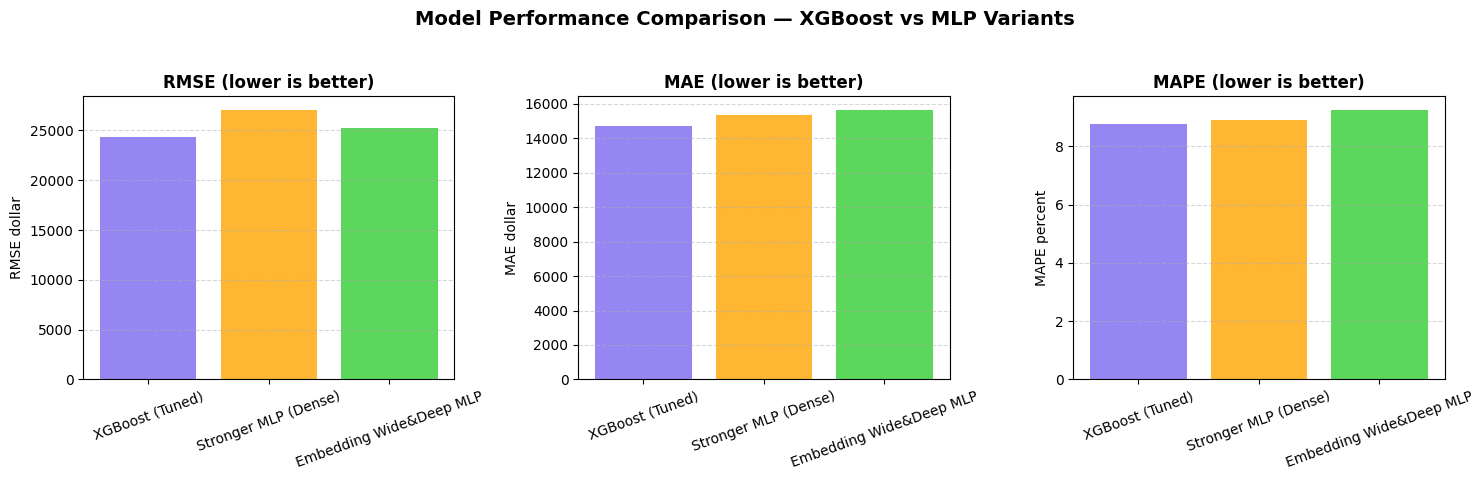

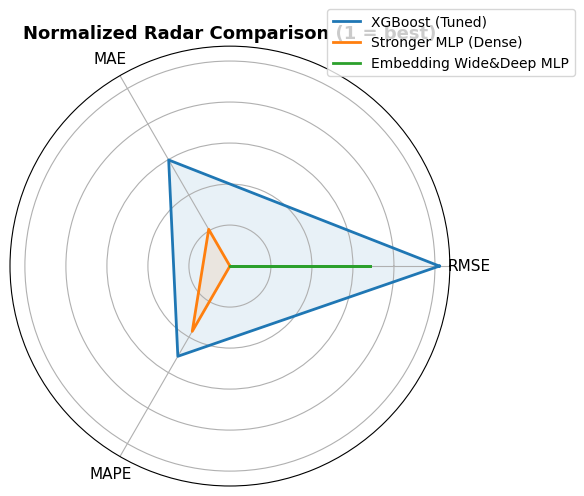


=== Final Comparison Table ===


,Model,RMSE_dollar,MAE_dollar,MAPE_percent
0,XGBoost (Tuned),"24,310","14,713",8.78
1,Stronger MLP (Dense),"27,076","15,324",8.91
2,Embedding Wide&Deep MLP,"25,228","15,648",9.25


In [18]:
# ============================================
# Model Comparison Visualization
# ============================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1️⃣  Enter your final metrics ---
data = {
    "Model": ["XGBoost (Tuned)", "Stronger MLP (Dense)", "Embedding Wide&Deep MLP"],
    "RMSE_dollar": [24310, 27076, 25228],
    "MAE_dollar":  [14713, 15324, 15648],
    "MAPE_percent": [8.78, 8.91, 9.25],
}

df = pd.DataFrame(data)

# --- 2️⃣  Bar chart comparison ---
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["RMSE_dollar", "MAE_dollar", "MAPE_percent"]
titles  = ["RMSE (lower is better)", "MAE (lower is better)", "MAPE (lower is better)"]

for i, metric in enumerate(metrics):
    ax[i].bar(df["Model"], df[metric], color=["#7b68ee", "#ffa500", "#32cd32"], alpha=0.8)
    ax[i].set_title(titles[i], fontsize=12, fontweight="bold")
    ax[i].set_ylabel(metric.replace("_", " "))
    ax[i].grid(axis="y", linestyle="--", alpha=0.5)
    ax[i].tick_params(axis="x", rotation=20)

plt.suptitle("Model Performance Comparison — XGBoost vs MLP Variants", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3️⃣  Radar chart (normalized performance) ---
# Normalize metrics (smaller = better, so we invert)
metrics_for_radar = ["RMSE_dollar", "MAE_dollar", "MAPE_percent"]
norm = df[metrics_for_radar].max()
normed = 1 - (df[metrics_for_radar] / norm)

labels = metrics_for_radar
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close loop

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(polar=True)

for i, row in df.iterrows():
    values = normed.loc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row["Model"], linewidth=2)
    ax.fill(angles, values, alpha=0.1)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["RMSE", "MAE", "MAPE"], fontsize=11)
plt.title("Normalized Radar Comparison (1 = best)", fontsize=13, fontweight="bold")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# --- 4️⃣  Annotated summary table ---
print("\n=== Final Comparison Table ===")
display(df.style
        .format({"RMSE_dollar":"{:,}", "MAE_dollar":"{:,}", "MAPE_percent":"{:.2f}"})
        .background_gradient(subset=["RMSE_dollar","MAE_dollar"], cmap="RdYlGn_r", high=0.2, low=0.2)
        .set_caption("Model Metrics (lower is better)"))